In [1]:
# ============================================================
# Recolector de datos reales con guía de voz visual
# ============================================================

import serial
import time
import numpy as np
import pandas as pd
from pathlib import Path

PUERTO   = 'COM3'
BAUDRATE = 9600
MUESTRAS = 300  # 30 segundos

ruta_real = Path('../data/real')
ruta_real.mkdir(parents=True, exist_ok=True)

def grabar_sesion(arduino, tipo, numero):
    """Graba una ventana de 30 segundos"""
    clases = {0: 'NORMAL', 1: 'APNEA LEVE', 2: 'APNEA SEVERA'}
    print(f"\n{'='*50}")
    print(f"  Grabación {numero} — {clases[tipo]}")
    
    if tipo == 0:
        print("  Respira normal durante 30 segundos")
    elif tipo == 1:
        print("  Respira 8 seg → AGUANTA 12 seg → Respira")
    else:
        print("  Respira 5 seg → AGUANTA 22 seg → Respira")
    
    print(f"{'='*50}")
    
    for i in range(3, 0, -1):
        print(f"  Iniciando en {i}...")
        time.sleep(1)
    
    print("  ¡GRABA AHORA!")
    
    valores = []
    while len(valores) < MUESTRAS:
        linea = arduino.readline().decode('utf-8').strip()
        if linea and linea != 'INICIO':
            try:
                valores.append(int(linea))
            except:
                pass
    
    print(f"  ✓ Grabación completa — {len(valores)} muestras")
    return np.array(valores)

print("✓ Recolector listo")
print("Cuando ejecutes la siguiente celda empezarán las grabaciones")

✓ Recolector listo
Cuando ejecutes la siguiente celda empezarán las grabaciones


In [2]:
# ============================================================
# Sesión de grabación completa
# ============================================================

arduino = serial.Serial(PUERTO, BAUDRATE, timeout=2)
time.sleep(2)

todas_las_senales = []
todas_las_etiquetas = []

# --- 10 grabaciones normales ---
print("\n🟢 BLOQUE 1 — RESPIRACIÓN NORMAL")
print("Respira con calma y naturalidad cada vez")
for i in range(10):
    senal = grabar_sesion(arduino, tipo=0, numero=i+1)
    todas_las_senales.append(senal)
    todas_las_etiquetas.append(0)
    if i < 9:
        print("  Descansa 5 segundos...")
        time.sleep(5)

# --- 10 grabaciones apnea leve ---
print("\n\n🟡 BLOQUE 2 — APNEA LEVE")
print("Patrón: respira 8 seg → aguanta 12 seg → respira")
time.sleep(5)
for i in range(10):
    senal = grabar_sesion(arduino, tipo=1, numero=i+1)
    todas_las_senales.append(senal)
    todas_las_etiquetas.append(1)
    if i < 9:
        print("  Descansa 8 segundos...")
        time.sleep(8)

# --- 10 grabaciones apnea severa ---
print("\n\n🔴 BLOQUE 3 — APNEA SEVERA")
print("Patrón: respira 5 seg → aguanta 22 seg → respira")
time.sleep(5)
for i in range(10):
    senal = grabar_sesion(arduino, tipo=2, numero=i+1)
    todas_las_senales.append(senal)
    todas_las_etiquetas.append(2)
    if i < 9:
        print("  Descansa 10 segundos...")
        time.sleep(10)

arduino.close()

# Guardar
X_real = np.array(todas_las_senales)
y_real = np.array(todas_las_etiquetas)

np.save(ruta_real / 'X_real.npy', X_real)
np.save(ruta_real / 'y_real.npy', y_real)

print(f"\n{'='*50}")
print(f"✓ Sesión completa")
print(f"✓ X_real: {X_real.shape}")
print(f"✓ y_real: {y_real.shape}")
print(f"✓ Datos guardados en data/real/")
print(f"{'='*50}")


🟢 BLOQUE 1 — RESPIRACIÓN NORMAL
Respira con calma y naturalidad cada vez

  Grabación 1 — NORMAL
  Respira normal durante 30 segundos
  Iniciando en 3...
  Iniciando en 2...
  Iniciando en 1...
  ¡GRABA AHORA!
  ✓ Grabación completa — 300 muestras
  Descansa 5 segundos...

  Grabación 2 — NORMAL
  Respira normal durante 30 segundos
  Iniciando en 3...
  Iniciando en 2...
  Iniciando en 1...
  ¡GRABA AHORA!
  ✓ Grabación completa — 300 muestras
  Descansa 5 segundos...

  Grabación 3 — NORMAL
  Respira normal durante 30 segundos
  Iniciando en 3...
  Iniciando en 2...
  Iniciando en 1...
  ¡GRABA AHORA!
  ✓ Grabación completa — 300 muestras
  Descansa 5 segundos...

  Grabación 4 — NORMAL
  Respira normal durante 30 segundos
  Iniciando en 3...
  Iniciando en 2...
  Iniciando en 1...
  ¡GRABA AHORA!
  ✓ Grabación completa — 300 muestras
  Descansa 5 segundos...

  Grabación 5 — NORMAL
  Respira normal durante 30 segundos
  Iniciando en 3...
  Iniciando en 2...
  Iniciando en 1...
  ¡GR

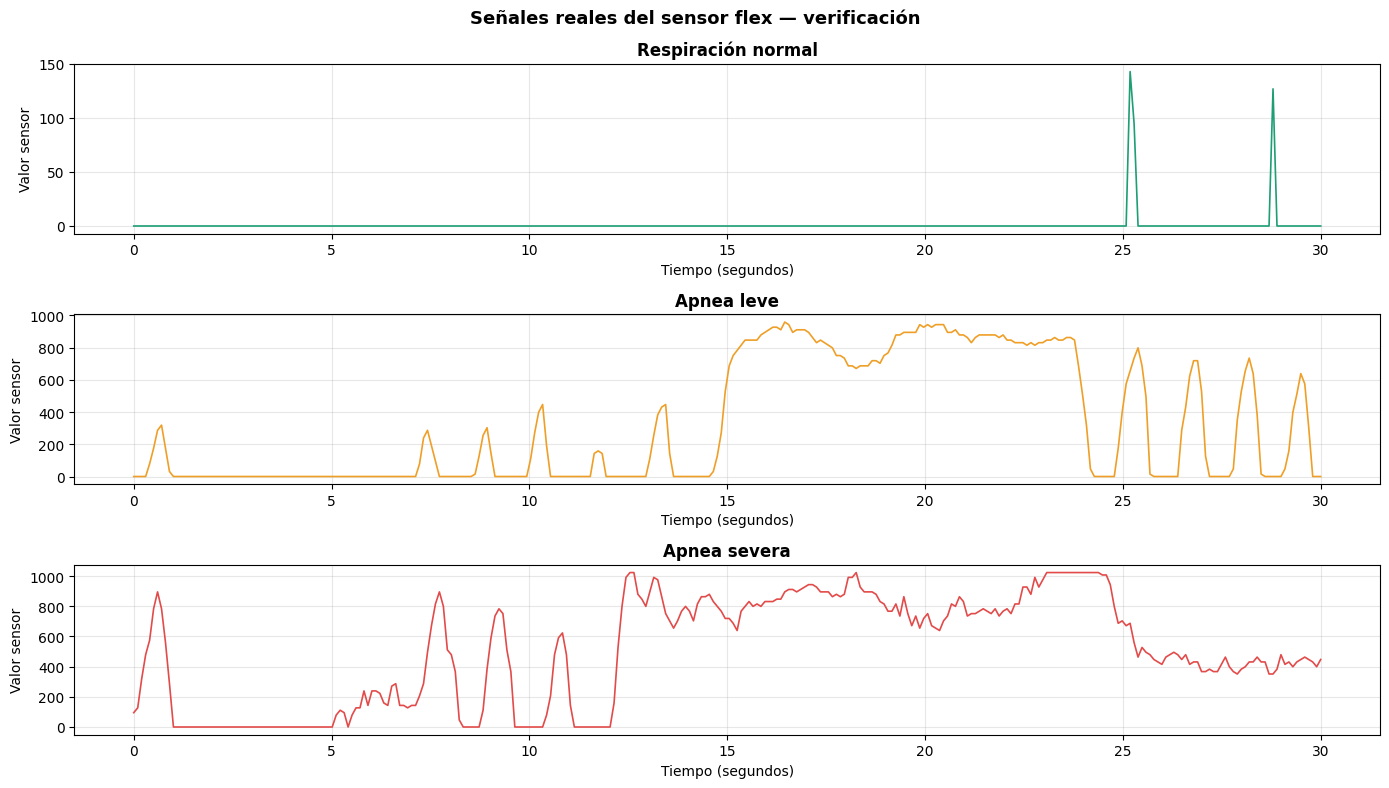

✓ Verificación completada


In [3]:
# ============================================================
# Verificación visual de las señales reales
# ============================================================

import matplotlib.pyplot as plt

X_real = np.load(ruta_real / 'X_real.npy')
y_real = np.load(ruta_real / 'y_real.npy')

t = np.linspace(0, 30, 300)
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

colores = ['#1D9E75', '#EF9F27', '#E24B4A']
titulos = ['Respiración normal', 'Apnea leve', 'Apnea severa']

for clase in range(3):
    idx = np.where(y_real == clase)[0][0]  # primera grabación de cada clase
    axes[clase].plot(t, X_real[idx], color=colores[clase], linewidth=1.2)
    axes[clase].set_title(titulos[clase], fontweight='bold')
    axes[clase].set_ylabel('Valor sensor')
    axes[clase].set_xlabel('Tiempo (segundos)')
    axes[clase].grid(True, alpha=0.3)

plt.suptitle('Señales reales del sensor flex — verificación',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/real/verificacion_senales_reales.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("✓ Verificación completada")

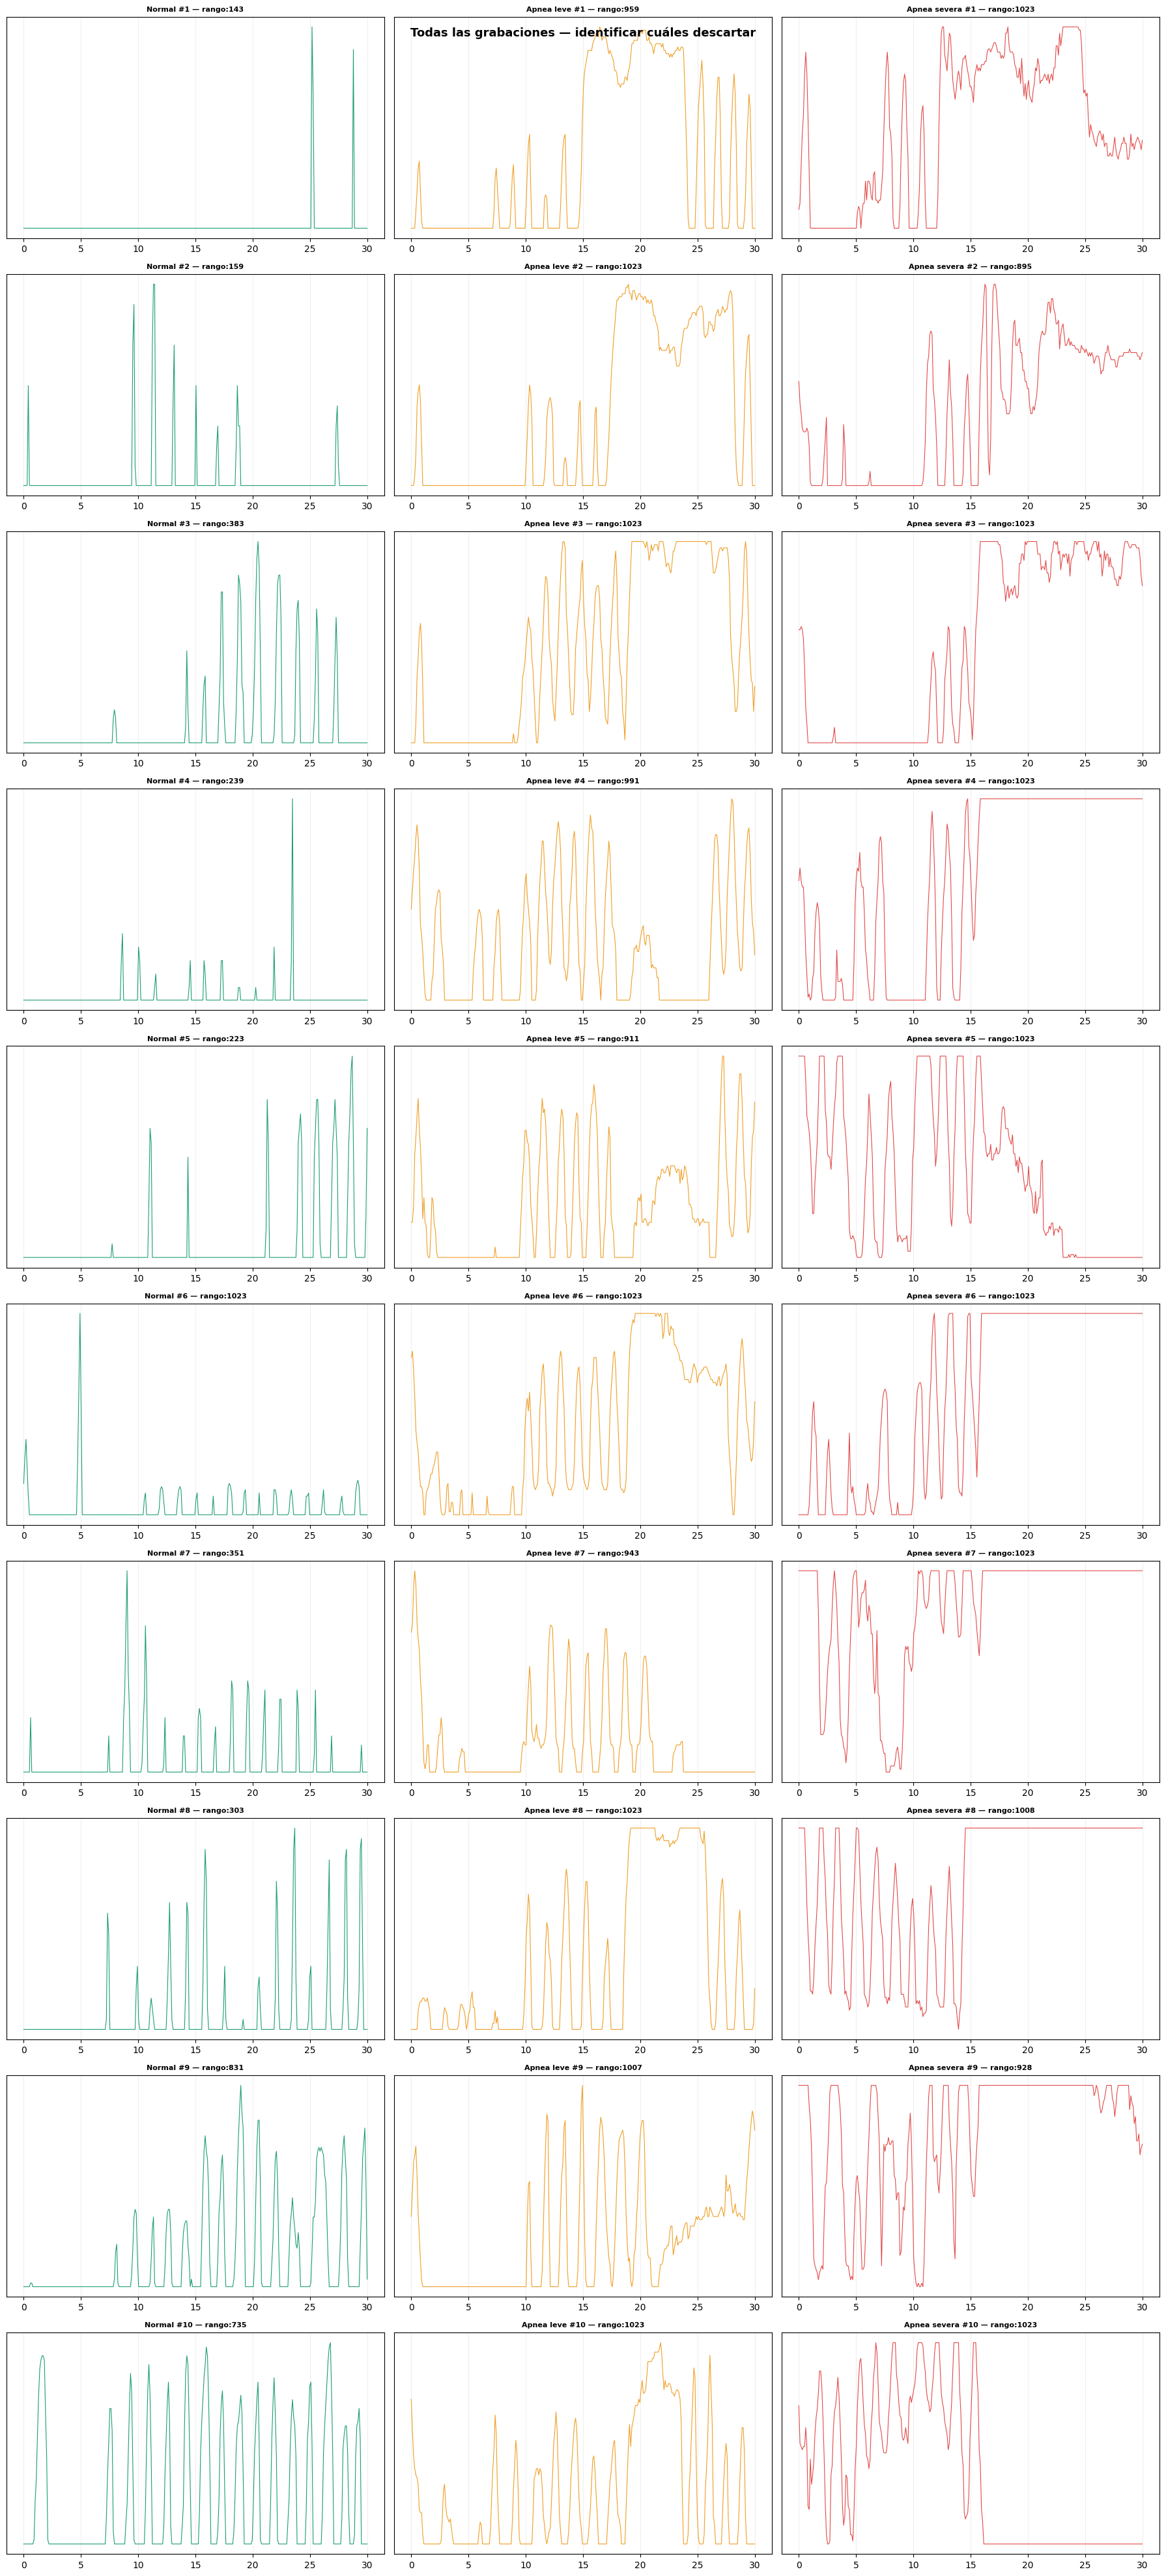

Rangos por grabación (rango bajo = señal mala):
---------------------------------------------

Normal:
  Grabación 1: rango 143 ✓
  Grabación 2: rango 159 ✓
  Grabación 3: rango 383 ✓
  Grabación 4: rango 239 ✓
  Grabación 5: rango 223 ✓
  Grabación 6: rango 1023 ✓
  Grabación 7: rango 351 ✓
  Grabación 8: rango 303 ✓
  Grabación 9: rango 831 ✓
  Grabación 10: rango 735 ✓

Apnea leve:
  Grabación 1: rango 959 ✓
  Grabación 2: rango 1023 ✓
  Grabación 3: rango 1023 ✓
  Grabación 4: rango 991 ✓
  Grabación 5: rango 911 ✓
  Grabación 6: rango 1023 ✓
  Grabación 7: rango 943 ✓
  Grabación 8: rango 1023 ✓
  Grabación 9: rango 1007 ✓
  Grabación 10: rango 1023 ✓

Apnea severa:
  Grabación 1: rango 1023 ✓
  Grabación 2: rango 895 ✓
  Grabación 3: rango 1023 ✓
  Grabación 4: rango 1023 ✓
  Grabación 5: rango 1023 ✓
  Grabación 6: rango 1023 ✓
  Grabación 7: rango 1023 ✓
  Grabación 8: rango 1008 ✓
  Grabación 9: rango 928 ✓
  Grabación 10: rango 1023 ✓


In [4]:
# ============================================================
# Revisión de todas las grabaciones
# ============================================================

fig, axes = plt.subplots(10, 3, figsize=(18, 40))
titulos = ['Normal', 'Apnea leve', 'Apnea severa']
colores = ['#1D9E75', '#EF9F27', '#E24B4A']

for clase in range(3):
    indices = np.where(y_real == clase)[0]
    for i, idx in enumerate(indices):
        ax = axes[i][clase]
        ax.plot(t, X_real[idx], color=colores[clase], linewidth=0.8)
        
        rango = X_real[idx].max() - X_real[idx].min()
        ax.set_title(f'{titulos[clase]} #{i+1} — rango:{rango:.0f}', 
                     fontsize=8, fontweight='bold')
        ax.set_yticks([])
        ax.grid(True, alpha=0.2)

plt.suptitle('Todas las grabaciones — identificar cuáles descartar',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Mostrar rangos de cada grabación
print("Rangos por grabación (rango bajo = señal mala):")
print("-" * 45)
for clase in range(3):
    indices = np.where(y_real == clase)[0]
    print(f"\n{titulos[clase]}:")
    for i, idx in enumerate(indices):
        rango = X_real[idx].max() - X_real[idx].min()
        estado = "✓" if rango > 100 else "✗ DESCARTAR"
        print(f"  Grabación {i+1}: rango {rango:.0f} {estado}")

In [5]:
# ============================================================
# Combinar datos reales + simulados y reentrenar
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pickle
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from pathlib import Path

ruta_sim  = Path('../data/simulated')
ruta_real = Path('../data/real')

# Cargar datos simulados originales
X_sim = pd.read_csv(ruta_sim / 'X_datos.csv').values
y_sim = pd.read_csv(ruta_sim / 'y_etiquetas.csv').values.ravel()

# Cargar datos reales
X_real = np.load(ruta_real / 'X_real.npy')
y_real = np.load(ruta_real / 'y_real.npy')

# Combinar
X_total = np.vstack([X_sim, X_real])
y_total = np.concatenate([y_sim, y_real])

print(f"✓ Datos simulados: {X_sim.shape[0]} ejemplos")
print(f"✓ Datos reales:    {X_real.shape[0]} ejemplos")
print(f"✓ Dataset total:   {X_total.shape[0]} ejemplos")
print(f"\n✓ Distribución final:")
print(f"   Normal:       {(y_total==0).sum()}")
print(f"   Apnea leve:   {(y_total==1).sum()}")
print(f"   Apnea severa: {(y_total==2).sum()}")

✓ Datos simulados: 600 ejemplos
✓ Datos reales:    30 ejemplos
✓ Dataset total:   630 ejemplos

✓ Distribución final:
   Normal:       310
   Apnea leve:   160
   Apnea severa: 160


In [6]:
# ============================================================
# Preprocesar y reentrenar con datos combinados
# ============================================================

# Normalizar
scaler_nuevo = MinMaxScaler()
X_norm = scaler_nuevo.fit_transform(X_total)

# División 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X_norm, y_total, test_size=0.30, random_state=42, stratify=y_total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# Reshape para LSTM
X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_lstm   = X_val.reshape(X_val.shape[0],   X_val.shape[1],   1)
X_test_lstm  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

print(f"✓ Entrenamiento: {X_train_lstm.shape[0]} ejemplos")
print(f"✓ Validación:    {X_val_lstm.shape[0]} ejemplos")
print(f"✓ Prueba:        {X_test_lstm.shape[0]} ejemplos")

# Modelo
modelo_real = Sequential([
    LSTM(64, return_sequences=True, input_shape=(300, 1)),
    BatchNormalization(),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

modelo_real.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=15,
                                restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('../model/modelo_real.keras',
                              monitor='val_accuracy', 
                              save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                               patience=5, min_lr=0.00001, verbose=1)

print("\nEntrenando con datos reales + simulados...")

historial_real = modelo_real.fit(
    X_train_lstm, y_train,
    epochs=80,
    batch_size=16,
    validation_data=(X_val_lstm, y_val),
    callbacks=[early_stopping, checkpoint, reduce_lr],
    verbose=1
)

print("\n✓ Entrenamiento completado")

✓ Entrenamiento: 441 ejemplos
✓ Validación:    94 ejemplos
✓ Prueba:        95 ejemplos


D:\Nuvia2\apnea-detection\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Entrenando con datos reales + simulados...
Epoch 1/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.3906 - loss: 1.0947
Epoch 1: val_accuracy improved from None to 0.48936, saving model to ../model/modelo_real.keras

Epoch 1: finished saving model to ../model/modelo_real.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 214ms/step - accuracy: 0.4580 - loss: 1.0724 - val_accuracy: 0.4894 - val_loss: 1.0761 - learning_rate: 0.0010
Epoch 2/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.4651 - loss: 1.0925
Epoch 2: val_accuracy did not improve from 0.48936
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 179ms/step - accuracy: 0.4717 - loss: 1.0895 - val_accuracy: 0.4894 - val_loss: 1.0683 - learning_rate: 0.0010
Epoch 3/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.4966 - loss: 1.0774
Epoch 3: val_accuracy did not improve from 0.48936
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 188ms/step - accuracy: 0.4966 - loss: 1.0772 - val_accuracy: 0.4894 - val_loss: 1.0701 - learning_rate: 0.0010
Epoch 4/80
28/

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 278ms/step
MODELO FINAL — datos reales + simulados
Accuracy:  48.4%
Loss:      1.0603

--- Reporte detallado ---

              precision    recall  f1-score   support

      Normal       0.49      0.98      0.65        47
  Apnea leve       0.00      0.00      0.00        24
Apnea severa       0.00      0.00      0.00        24

    accuracy                           0.48        95
   macro avg       0.16      0.33      0.22        95
weighted avg       0.24      0.48      0.32        95



D:\Nuvia2\apnea-detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Nuvia2\apnea-detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Nuvia2\apnea-detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


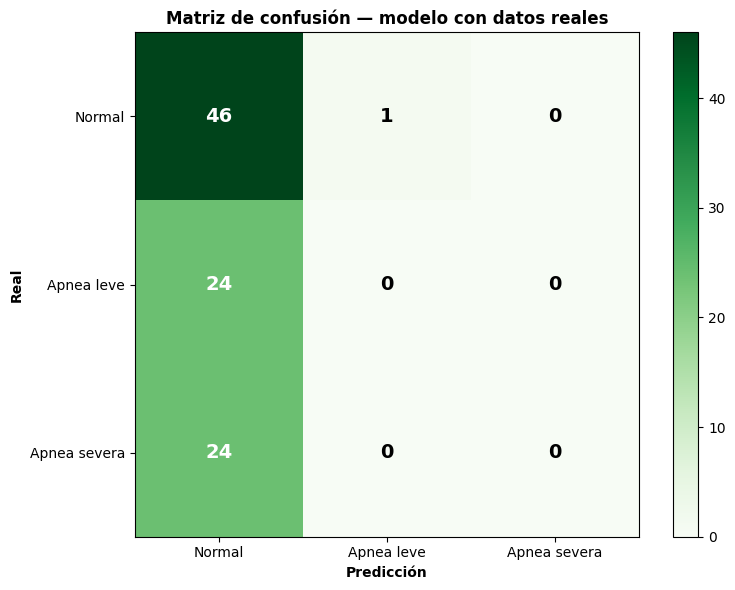

✓ Scaler guardado en data/real/scaler_real.pkl


In [7]:
# ============================================================
# Evaluación del modelo entrenado con datos reales
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

loss, accuracy = modelo_real.evaluate(X_test_lstm, y_test, verbose=0)
y_pred = np.argmax(modelo_real.predict(X_test_lstm), axis=1)

clases = ['Normal', 'Apnea leve', 'Apnea severa']

print("=" * 50)
print("MODELO FINAL — datos reales + simulados")
print("=" * 50)
print(f"Accuracy:  {accuracy*100:.1f}%")
print(f"Loss:      {loss:.4f}")
print(f"\n--- Reporte detallado ---\n")
print(classification_report(y_test, y_pred, target_names=clases))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Greens')
plt.colorbar(im)

ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(clases)
ax.set_yticklabels(clases)

for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_xlabel('Predicción', fontweight='bold')
ax.set_ylabel('Real', fontweight='bold')
ax.set_title('Matriz de confusión — modelo con datos reales', 
             fontweight='bold')
plt.tight_layout()
plt.savefig('../data/real/matriz_confusion_real.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# Guardar scaler nuevo
with open('../data/real/scaler_real.pkl', 'wb') as f:
    pickle.dump(scaler_nuevo, f)

print("✓ Scaler guardado en data/real/scaler_real.pkl")

In [8]:
# ============================================================
# Entrenar SOLO con datos reales
# ============================================================

# Normalizar solo los datos reales
scaler_real = MinMaxScaler()
X_real_norm = scaler_real.fit_transform(X_real)

# División — con solo 30 ejemplos usamos 70/30
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_real_norm, y_real, 
    test_size=0.30, 
    random_state=42, 
    stratify=y_real
)

X_train_r = X_train_r.reshape(X_train_r.shape[0], X_train_r.shape[1], 1)
X_test_r  = X_test_r.reshape(X_test_r.shape[0],  X_test_r.shape[1],  1)

print(f"✓ Entrenamiento: {X_train_r.shape[0]} ejemplos")
print(f"✓ Prueba:        {X_test_r.shape[0]} ejemplos")

# Modelo más simple — con pocos datos una red simple funciona mejor
modelo_solo_real = Sequential([
    LSTM(32, return_sequences=True, input_shape=(300, 1)),
    Dropout(0.2),
    LSTM(16, return_sequences=False),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

modelo_solo_real.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(monitor='val_loss', patience=20,
                                restore_best_weights=True, verbose=1)

print("\nEntrenando solo con datos reales...")

historial_solo = modelo_solo_real.fit(
    X_train_r, y_train_r,
    epochs=100,
    batch_size=4,          # batch pequeño para pocos datos
    validation_split=0.15,
    callbacks=[early_stopping],
    verbose=1
)

loss_r, acc_r = modelo_solo_real.evaluate(X_test_r, y_test_r, verbose=0)
y_pred_r = np.argmax(modelo_solo_real.predict(X_test_r), axis=1)

print(f"\n✓ Accuracy con datos reales: {acc_r*100:.1f}%")
print(f"\n{classification_report(y_test_r, y_pred_r, target_names=clases)}")

✓ Entrenamiento: 21 ejemplos
✓ Prueba:        9 ejemplos

Entrenando solo con datos reales...


D:\Nuvia2\apnea-detection\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 245ms/step - accuracy: 0.2941 - loss: 1.1054 - val_accuracy: 0.5000 - val_loss: 1.0927
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.3529 - loss: 1.0957 - val_accuracy: 0.5000 - val_loss: 1.0839
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.3529 - loss: 1.0967 - val_accuracy: 0.7500 - val_loss: 1.0784
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.3529 - loss: 1.0844 - val_accuracy: 0.5000 - val_loss: 1.0741
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.4706 - loss: 1.0703 - val_accuracy: 0.5000 - val_loss: 1.0658
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.3529 - loss: 1.0671 - val_accuracy: 0.5000 - val_loss: 1.0536
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.3529 - loss: 1.0676 - val_accuracy: 0.5000 - val_loss: 1.0426
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.4118 - loss: 1.0642 - val_accuracy: 0.5000 - v

In [10]:
# ============================================================
# Data Augmentation — 30 ejemplos reales → 300
# ============================================================

def augmentar_senal(senal, n_variaciones=9):
    """
    Genera n variaciones realistas de una señal respiratoria.
    Cada transformación simula variaciones naturales del sensor.
    """
    variaciones = []
    
    for i in range(n_variaciones):
        s = senal.copy().astype(float)
        
        # 1. Ruido gaussiano — simula variación eléctrica del sensor
        if i % 3 == 0:
            s += np.random.normal(0, s.std() * 0.05, len(s))
        
        # 2. Escala de amplitud — simula diferente presión del sensor
        if i % 3 == 1:
            factor = np.random.uniform(0.85, 1.15)
            s = s * factor
        
        # 3. Desplazamiento temporal — simula inicio diferente
        if i % 3 == 2:
            shift = np.random.randint(-15, 15)
            s = np.roll(s, shift)
        
        # 4. Combinación de ruido + escala
        if i >= 6:
            s += np.random.normal(0, s.std() * 0.03, len(s))
            s = s * np.random.uniform(0.90, 1.10)
        
        # Limitar al rango original
        s = np.clip(s, senal.min(), senal.max())
        variaciones.append(s)
    
    return variaciones


# Aplicar augmentation a cada grabación real
X_aug = []
y_aug = []

for i in range(len(X_real)):
    # Incluir la señal original
    X_aug.append(X_real[i])
    y_aug.append(y_real[i])
    
    # Generar 9 variaciones = 10 ejemplos por grabación
    variaciones = augmentar_senal(X_real[i], n_variaciones=9)
    for v in variaciones:
        X_aug.append(v)
        y_aug.append(y_real[i])

X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

print(f"✓ Antes del augmentation: {len(X_real)} ejemplos")
print(f"✓ Después del augmentation: {len(X_aug)} ejemplos")
print(f"\n✓ Distribución aumentada:")
print(f"   Normal:       {(y_aug==0).sum()}")
print(f"   Apnea leve:   {(y_aug==1).sum()}")
print(f"   Apnea severa: {(y_aug==2).sum()}")

# Guardar
np.save(ruta_real / 'X_augmented.npy', X_aug)
np.save(ruta_real / 'y_augmented.npy', y_aug)
print(f"\n✓ Datos aumentados guardados")

✓ Antes del augmentation: 30 ejemplos
✓ Después del augmentation: 300 ejemplos

✓ Distribución aumentada:
   Normal:       100
   Apnea leve:   100
   Apnea severa: 100

✓ Datos aumentados guardados


In [11]:
# ============================================================
# Reentrenar con datos aumentados
# ============================================================

# Normalizar
scaler_aug = MinMaxScaler()
X_aug_norm = scaler_aug.fit_transform(X_aug)

# División 70/15/15
X_train_a, X_temp_a, y_train_a, y_temp_a = train_test_split(
    X_aug_norm, y_aug,
    test_size=0.30,
    random_state=42,
    stratify=y_aug
)
X_val_a, X_test_a, y_val_a, y_test_a = train_test_split(
    X_temp_a, y_temp_a,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_a
)

# Reshape
X_train_a = X_train_a.reshape(X_train_a.shape[0], X_train_a.shape[1], 1)
X_val_a   = X_val_a.reshape(X_val_a.shape[0],     X_val_a.shape[1],   1)
X_test_a  = X_test_a.reshape(X_test_a.shape[0],   X_test_a.shape[1],  1)

print(f"✓ Entrenamiento: {X_train_a.shape[0]} ejemplos")
print(f"✓ Validación:    {X_val_a.shape[0]} ejemplos")
print(f"✓ Prueba:        {X_test_a.shape[0]} ejemplos")

# Modelo
modelo_aug = Sequential([
    LSTM(64, return_sequences=True, input_shape=(300, 1)),
    BatchNormalization(),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

modelo_aug.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(monitor='val_loss', patience=15,
                                restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('../model/modelo_augmented.keras',
                              monitor='val_accuracy',
                              save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                               patience=5, min_lr=0.00001, verbose=1)

print("\nEntrenando con datos aumentados...")

historial_aug = modelo_aug.fit(
    X_train_a, y_train_a,
    epochs=80,
    batch_size=16,
    validation_data=(X_val_a, y_val_a),
    callbacks=[early_stopping, checkpoint, reduce_lr],
    verbose=1
)

print("\n✓ Entrenamiento completado")

✓ Entrenamiento: 210 ejemplos
✓ Validación:    45 ejemplos
✓ Prueba:        45 ejemplos


D:\Nuvia2\apnea-detection\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Entrenando con datos aumentados...
Epoch 1/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.4479 - loss: 1.5344
Epoch 1: val_accuracy improved from None to 0.33333, saving model to ../model/modelo_augmented.keras

Epoch 1: finished saving model to ../model/modelo_augmented.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 239ms/step - accuracy: 0.4619 - loss: 1.4874 - val_accuracy: 0.3333 - val_loss: 1.1126 - learning_rate: 0.0010
Epoch 2/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.5305 - loss: 1.1032
Epoch 2: val_accuracy did not improve from 0.33333
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - accuracy: 0.5333 - loss: 1.0119 - val_accuracy: 0.3333 - val_loss: 1.1002 - learning_rate: 0.0010
Epoch 3/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.6579 - loss: 0.9465
Epoch 3: val_accuracy did not improve from 0.33333
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step - accuracy: 0.7000 - loss: 0.8797 - val_accuracy: 0.3333 - val_loss: 1.0939 - learning_rate: 0.0010
Epoch 4/80
14

In [12]:
# ============================================================
# Evaluación del modelo con datos aumentados
# ============================================================

loss_a, acc_a = modelo_aug.evaluate(X_test_a, y_test_a, verbose=0)
y_pred_a = np.argmax(modelo_aug.predict(X_test_a), axis=1)

print("=" * 50)
print("MODELO CON DATA AUGMENTATION")
print("=" * 50)
print(f"Accuracy:  {acc_a*100:.1f}%")
print(f"Loss:      {loss_a:.4f}")
print(f"\n--- Reporte detallado ---\n")
print(classification_report(y_test_a, y_pred_a, target_names=clases))

# Comparación de los tres modelos
print("\n" + "=" * 50)
print("COMPARACIÓN FINAL DE MODELOS")
print("=" * 50)
print(f"Modelo simulado original:    93.3%")
print(f"Modelo solo datos reales:    66.7%")
print(f"Modelo data augmentation:    {acc_a*100:.1f}%")

# Exportar a TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(modelo_aug)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False
tflite_aug = converter.convert()

with open('../model/modelo_final.tflite', 'wb') as f:
    f.write(tflite_aug)

# Guardar scaler
with open('../data/real/scaler_aug.pkl', 'wb') as f:
    pickle.dump(scaler_aug, f)

tamanio = Path('../model/modelo_final.tflite').stat().st_size / 1024
print(f"\n✓ Modelo final exportado: {tamanio:.1f} KB")
print(f"✓ Este es el modelo que irá en la app móvil")

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/stepWARNING:tensorflow:5 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001FD4E09C360> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step
MODELO CON DATA AUGMENTATION
Accuracy:  86.7%
Loss:      0.3944

--- Reporte detallado ---

              precision    recall  f1-score   support

      Normal       0.79      1.00      0.88       

INFO:tensorflow:Assets written to: C:\Users\Leone\AppData\Local\Temp\tmpr0hyiuld\assets


Saved artifact at 'C:\Users\Leone\AppData\Local\Temp\tmpr0hyiuld'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 1), dtype=tf.float32, name='keras_tensor_15')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2187225698704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2187225694288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2187225696784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2187355730384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2187355730960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2187225697552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2187355732112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2187355730192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2187355729808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2187355731152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2187355